<a href="https://www.kaggle.com/code/mrafraim/predictive-supply-chain-analytics?scriptVersionId=301645261" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predictive Supply Chain Analytics: Revenue and Risk Forecasting

# 1. Project Overview

### Objective

The objective of this project is to develop a predictive and diagnostic analytical framework for evaluating revenue performance and operational risk within the supply chain of a **Fashion & Beauty startup specializing in makeup products**.

This project focuses on:

* Identifying key drivers of revenue generation across products and SKUs.
* Quantifying operational risks such as high defect rates, extended lead times, and cost volatility.
* Building predictive models to forecast revenue and assess supply chain risk exposure.
* Translating analytical findings into strategic actions for cost optimization and performance stability.

The core business question addressed:

> Which operational factors most strongly influence revenue performance, and how can supply chain risks be predicted and mitigated proactively?

### Domain

Supply Chain Analytics
Industry: Fashion & Beauty (Makeup Products)

### Tools Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Plotly
* Scikit-learn
* SciPy (for statistical validation)


### Dataset Source

[Kaggle - Supply Chain Dataset](https://www.kaggle.com/datasets/harshsingh2209/supply-chain-analysis)

### Dataset Size

Records – 100 | Features – 24


# 2. Data Understanding

## 2.1 Dataset Description

The dataset contains 100 observations of makeup product SKUs. While the sample size is small, the feature density (24 variables) allows for a multidimensional view of the supply chain, covering procurement, production, logistics, and sales.

| Variable | Description |
| --- | --- |
| Product Type | Category of the makeup product (e.g., Skincare, Haircare) |
| SKU | Unique Stock Keeping Unit identifier |
| Price | Sale price of the product | 
| Availability | Current availability status or percentage |
| Number of products sold | Quantity sold to date |
| Revenue generated | Total revenue from the SKU |
| Customer demographics | Target or actual customer segment (e.g., Male, Female, Unknown) |
| Stock levels | Units currently in inventory | 
| Lead times | Time taken from order to delivery |
| Order quantities | Typical quantity per order | 
| Shipping times | Time spent in transit | 
| Shipping carriers | Company responsible for delivery |
| Shipping costs | Expenses related to shipping |
| Supplier name | Name of the raw material or product supplier |
| Location | Geographic origin or warehouse location | 
| Lead time | General procurement lead time | 
| Production volumes | Number of units produced per batch | 
| Manufacturing lead time | Time taken to manufacture the product | 
| Manufacturing costs | Cost incurred during production | 
| Inspection results | Quality control outcome (Pass/Fail/Pending) | 
| Defect rates | Percentage of defective units per batch | 
| Transportation modes | Method of transport (Air, Rail, Road, Sea) | 
| Routes | Logistics path taken |
| Costs | Total operational costs associated |


In [1]:
#Import Necessary Libraries
import pandas as pd # Pandas is used for data manipulation and analysis
import numpy as np # Numpy is used for numerical operations
import matplotlib.pyplot as plt # Matplotlib is used for creating static, animated, and interactive visualizations
import seaborn as sns # Seaborn is used for making statistical graphics
from scipy import stats # Scipy is used for scientific and technical computing

# Warnings is used to manage warning messages
import warnings
warnings.filterwarnings('ignore')

# Plotly is used for interactive visualizations
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

# Confirming the imports
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/supply-chain-analysis/supply_chain_data.csv')

# Set option to display all columns
pd.set_option('display.max_columns', None)

# Display the first few rows of the dataframe
df.head(5)

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

## 2.2 Initial Observations

### 1. Missing Values

In [4]:
# Check for missing values
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

No missing values are present in any of the 24 features. The dataset is complete for all records.

### 2. Duplicate Values

In [5]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

No duplicate records detected. Each row represents a unique SKU and product entry.

### 3. Target Variable Distribution

Since the predictive focus is revenue forecasting, the target variable is Revenue generated (continuous).

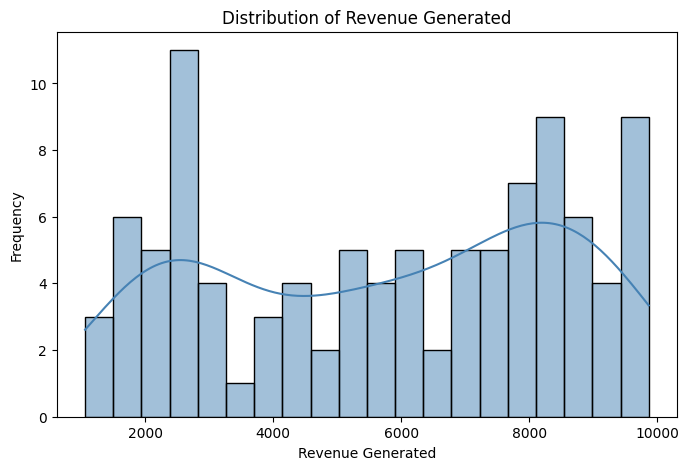

In [6]:
# Check target variable distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Revenue generated'], bins=20, kde=True, color='steelblue')
plt.title("Distribution of Revenue Generated")
plt.xlabel("Revenue Generated")
plt.ylabel("Frequency")
plt.show()

The data follows a bimodal distribution which indicates two main groups: most sales are either small or large. There is a big gap in the middle, meaning customers rarely spend a medium amount.

### 4. Observations & Risk Assessment

A preliminary scan of the data structure reveals several critical points for the upcoming predictive modeling:

* **Data Integrity:** With 100 non-null records across all columns, the dataset is "clean" from a technical standpoint, but the small sample size suggests we should prioritize **Robust Scalers** and potentially **Cross-Validation** to avoid overfitting in the modeling phase.
* **Target Variable Distribution:** "Revenue generated" will serve as our primary continuous target. We will need to check for skewness, as supply chain revenue often follows a power-law distribution (a few SKUs generating most of the value).
* **Operational Constraints:** Variables like `Lead time` and `Manufacturing lead time` are crucial. Discrepancies between these could indicate bottlenecks in the "Procurement vs. Production" phases.
* **Quality Risk:** The `Defect rates` and `Inspection results` provide a supervised label for risk. We will evaluate if high defect rates correlate significantly with specific `Supplier names` or `Transportation modes`.

# 3. Data Preparation

## 3.1 Data Cleaning

Given the high data integrity reported in the technical metadata (zero null values), the cleaning phase focuses on **structural consistency** and **outlier detection**. In a supply chain context, extreme outliers in "Defect Rates" or "Manufacturing Costs" are not always errors; they often represent high-risk events that our predictive model needs to capture or normalize.

* **Handling Missing/Null Values:** Confirmed at 0% across all 24 features.
* **Removing Duplicates:** Verified unique SKUs to ensure no redundant records inflate performance metrics.
* **Addressing Outliers:** Apply the Interquartile Range (IQR) method to identify extreme values in `Revenue generated`, `Manufacturing costs` and `Shipping costs`.


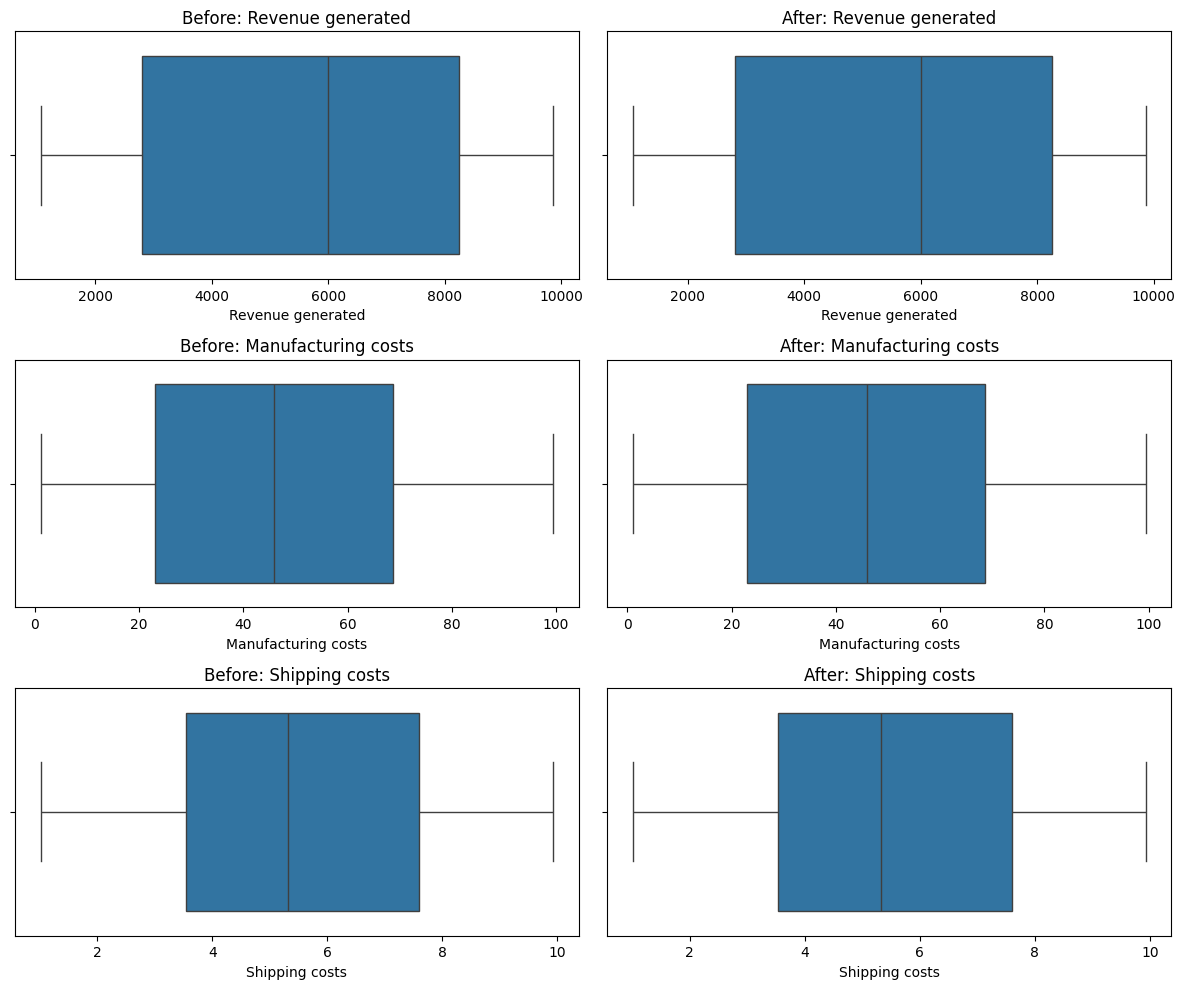

In [7]:
cols = ['Revenue generated', 'Manufacturing costs', 'Shipping costs']

# save original data
df_before = df.copy()

# outlier handling function
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Capping outliers to the upper/lower bounds to preserve data volume in a small 100-row set
    df[column] = df[column].clip(lower, upper)
    return df

# apply outlier handling
for col in cols:
    df = handle_outliers(df, col)

# create subplot
fig, axes = plt.subplots(3, 2, figsize=(12,10))

for i, col in enumerate(cols):

    # BEFORE
    sns.boxplot(x=df_before[col], ax=axes[i,0])
    axes[i,0].set_title(f"Before: {col}")

    # AFTER
    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f"After: {col}")

plt.tight_layout()
plt.show()

The identical "Before" and "After" boxplots confirm the dataset contains zero statistical outliers in financial features. This lack of noise ensures high data stability for the predictive modeling phase.

---

<p style="text-align:center; color:skyblue; font-size:18px;">
© 2026 Mostafizur Rahman
</p>
